In [23]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm # Assuming tqdm is imported

In [24]:
# -------------------- Paths -----------------------
PROC_DIR = "../datasets_processed"
train_df = pd.read_csv("../datasets/train.csv")
val_df   = pd.read_csv("../datasets/val.csv")
test_df  = pd.read_csv("../datasets/test.csv")

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 36916
Validation samples: 6515
Test samples: 7665


In [25]:
# --- FIX: Re-encode the string labels to integers after reading CSVs ---
le = LabelEncoder()

In [26]:
all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']])
le.fit(all_labels)

LabelEncoder()

In [27]:
# Apply the transformation back to the dataframes' 'label' column
train_df['label'] = le.transform(train_df['label'])
val_df['label'] = le.transform(val_df['label'])
test_df['label'] = le.transform(test_df['label'])

In [28]:
# ---------------- Dataset Loader ------------------
class SignDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        
        # This line now works because 'row.label' is an integer (0, 1, 2, ...)
        y = int(row.label) 
        
        # Ensure label tensor is of type long for CrossEntropyLoss
        return torch.tensor(x), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

In [29]:
train_loader = DataLoader(SignDataset(train_df), batch_size=32, shuffle=True)
val_loader   = DataLoader(SignDataset(val_df),   batch_size=32, shuffle=False)
test_loader  = DataLoader(SignDataset(test_df),  batch_size=32, shuffle=False)

In [30]:
sample_batch_X, sample_batch_y = next(iter(train_loader))
input_dim = sample_batch_X.shape[-1] # Gets the actual last dimension: 387

num_classes = train_df.label.nunique()
print(f"Dynamically determined input_dim: {input_dim}")
print(f"Number of classes: {num_classes}")

Dynamically determined input_dim: 387
Number of classes: 401


In [31]:
# ---------------- Model ---------------------------
input_dim = (54+21+21+33) * 3   # face + lh + rh + pose (x,y,z)
num_classes = train_df.label.nunique()

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            256, 
            batch_first=True, 
            num_layers=2,
            dropout=0.3
        )
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])  # last timestep output


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = LSTMModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [32]:
# ---------------- EarlyStopping Class (Directory Aware) -----------------------
class EarlyStopping:
    """Stops training when validation loss does not improve for a given patience."""
    def __init__(self, patience=5, verbose=False, delta=0, filename='checkpoint.pt', save_dir='Models'):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.save_dir = save_dir
        # Combine directory and filename for the full path
        self.path = os.path.join(save_dir, filename) 
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        
        # Ensure the save directory exists before any saving happens
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir, exist_ok=True)
            if self.verbose:
                print(f"Created directory: {self.save_dir}")

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decreases."""
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model to {self.path}...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [34]:
# ---------------- Training Loop with Early Stopping -------------------
EPOCHS = 150
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Initialize Early Stopping, configuring it to use the final desired path
early_stopping = EarlyStopping(
    patience=7, 
    verbose=True,
    save_dir='../Models',          # Saves to the parent directory's 'Models' folder
    filename='lstm_bdslw401.pth'   # Desired filename
)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()

    train_losses.append(total_loss)
    train_accs.append(correct / len(train_df))


    # ---------------- Validation ----------------
    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            v_loss += loss_fn(preds, y).item()
            v_correct += (preds.argmax(1) == y).sum().item()

    # Calculate average validation loss for the epoch
    avg_val_loss = v_loss / len(val_loader) 
    val_losses.append(avg_val_loss) # Note: appending average loss
    val_accs.append(v_correct / len(val_df))

    print(f"Epoch {epoch+1}: Train Loss={total_loss:.4f}, Val Loss={avg_val_loss:.4f}, Train Acc={train_accs[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

    # Check early stopping condition (saves best model automatically)
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered. Breaking training loop.")
        break

Epoch 1/150: 100%|██████████| 1154/1154 [04:57<00:00,  3.87it/s]


Epoch 1: Train Loss=6169.1933, Val Loss=4.8848, Train Acc=0.0225, Val Acc=0.0413
Validation loss decreased (inf --> 4.884845). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 2/150: 100%|██████████| 1154/1154 [04:02<00:00,  4.76it/s]


Epoch 2: Train Loss=5382.8684, Val Loss=4.4256, Train Acc=0.0611, Val Acc=0.0880
Validation loss decreased (4.884845 --> 4.425639). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 3/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.49it/s]


Epoch 3: Train Loss=4890.5185, Val Loss=4.0536, Train Acc=0.1053, Val Acc=0.1286
Validation loss decreased (4.425639 --> 4.053574). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 4/150: 100%|██████████| 1154/1154 [00:18<00:00, 63.60it/s]


Epoch 4: Train Loss=4461.7460, Val Loss=3.7466, Train Acc=0.1564, Val Acc=0.1678
Validation loss decreased (4.053574 --> 3.746601). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 5/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.44it/s]


Epoch 5: Train Loss=4071.4391, Val Loss=3.4062, Train Acc=0.2103, Val Acc=0.2284
Validation loss decreased (3.746601 --> 3.406150). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 6/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.04it/s]


Epoch 6: Train Loss=3729.6145, Val Loss=3.1343, Train Acc=0.2603, Val Acc=0.2754
Validation loss decreased (3.406150 --> 3.134295). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 7/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.58it/s]


Epoch 7: Train Loss=3418.9013, Val Loss=2.8916, Train Acc=0.3128, Val Acc=0.3228
Validation loss decreased (3.134295 --> 2.891569). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 8/150: 100%|██████████| 1154/1154 [00:19<00:00, 59.00it/s]


Epoch 8: Train Loss=3152.9832, Val Loss=2.7341, Train Acc=0.3595, Val Acc=0.3464
Validation loss decreased (2.891569 --> 2.734111). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 9/150: 100%|██████████| 1154/1154 [00:18<00:00, 63.16it/s]


Epoch 9: Train Loss=2911.2812, Val Loss=2.5060, Train Acc=0.4018, Val Acc=0.4002
Validation loss decreased (2.734111 --> 2.506011). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 10/150: 100%|██████████| 1154/1154 [00:18<00:00, 63.96it/s]


Epoch 10: Train Loss=2701.8444, Val Loss=2.4257, Train Acc=0.4382, Val Acc=0.4071
Validation loss decreased (2.506011 --> 2.425734). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 11/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.45it/s]


Epoch 11: Train Loss=2511.1819, Val Loss=2.1730, Train Acc=0.4723, Val Acc=0.4662
Validation loss decreased (2.425734 --> 2.172956). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 12/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.59it/s]


Epoch 12: Train Loss=2353.4016, Val Loss=2.1282, Train Acc=0.4996, Val Acc=0.4688
Validation loss decreased (2.172956 --> 2.128205). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 13/150: 100%|██████████| 1154/1154 [00:18<00:00, 64.07it/s]


Epoch 13: Train Loss=2199.9132, Val Loss=1.9765, Train Acc=0.5304, Val Acc=0.5094
Validation loss decreased (2.128205 --> 1.976515). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 14/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.94it/s]


Epoch 14: Train Loss=2065.2273, Val Loss=1.8998, Train Acc=0.5568, Val Acc=0.5165
Validation loss decreased (1.976515 --> 1.899773). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 15/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.11it/s]


Epoch 15: Train Loss=1943.0796, Val Loss=1.7540, Train Acc=0.5836, Val Acc=0.5555
Validation loss decreased (1.899773 --> 1.753959). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 16/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.03it/s]


Epoch 16: Train Loss=1822.7511, Val Loss=1.6617, Train Acc=0.6106, Val Acc=0.5796
Validation loss decreased (1.753959 --> 1.661712). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 17/150: 100%|██████████| 1154/1154 [00:17<00:00, 67.11it/s]


Epoch 17: Train Loss=1710.4479, Val Loss=1.6462, Train Acc=0.6295, Val Acc=0.5762
Validation loss decreased (1.661712 --> 1.646202). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 18/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.41it/s]


Epoch 18: Train Loss=1615.8670, Val Loss=1.5345, Train Acc=0.6488, Val Acc=0.6095
Validation loss decreased (1.646202 --> 1.534466). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 19/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.72it/s]


Epoch 19: Train Loss=1528.9940, Val Loss=1.4848, Train Acc=0.6671, Val Acc=0.6141
Validation loss decreased (1.534466 --> 1.484795). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 20/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.78it/s]


Epoch 20: Train Loss=1433.8687, Val Loss=1.4200, Train Acc=0.6887, Val Acc=0.6309
Validation loss decreased (1.484795 --> 1.419974). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 21/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.27it/s]


Epoch 21: Train Loss=1361.0595, Val Loss=1.3742, Train Acc=0.7043, Val Acc=0.6428
Validation loss decreased (1.419974 --> 1.374160). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 22/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.03it/s]


Epoch 22: Train Loss=1280.1990, Val Loss=1.2914, Train Acc=0.7224, Val Acc=0.6651
Validation loss decreased (1.374160 --> 1.291439). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 23/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.54it/s]


Epoch 23: Train Loss=1215.5503, Val Loss=1.2769, Train Acc=0.7360, Val Acc=0.6685
Validation loss decreased (1.291439 --> 1.276903). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 24/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.54it/s]


Epoch 24: Train Loss=1152.3630, Val Loss=1.2251, Train Acc=0.7505, Val Acc=0.6847
Validation loss decreased (1.276903 --> 1.225099). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 25/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.26it/s]


Epoch 25: Train Loss=1093.6302, Val Loss=1.1909, Train Acc=0.7612, Val Acc=0.6924
Validation loss decreased (1.225099 --> 1.190925). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 26/150: 100%|██████████| 1154/1154 [00:17<00:00, 67.04it/s]


Epoch 26: Train Loss=1031.5730, Val Loss=1.1551, Train Acc=0.7760, Val Acc=0.6967
Validation loss decreased (1.190925 --> 1.155064). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 27/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.92it/s]


Epoch 27: Train Loss=976.6263, Val Loss=1.1170, Train Acc=0.7901, Val Acc=0.7070
Validation loss decreased (1.155064 --> 1.116982). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 28/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.45it/s]


Epoch 28: Train Loss=933.9110, Val Loss=1.0970, Train Acc=0.7951, Val Acc=0.7101
Validation loss decreased (1.116982 --> 1.096975). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 29/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.73it/s]


Epoch 29: Train Loss=878.9607, Val Loss=1.0183, Train Acc=0.8111, Val Acc=0.7348
Validation loss decreased (1.096975 --> 1.018313). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 30/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.69it/s]


Epoch 30: Train Loss=837.1202, Val Loss=1.0375, Train Acc=0.8198, Val Acc=0.7340
EarlyStopping counter: 1 of 7


Epoch 31/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.75it/s]


Epoch 31: Train Loss=794.6315, Val Loss=0.9671, Train Acc=0.8296, Val Acc=0.7546
Validation loss decreased (1.018313 --> 0.967124). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 32/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.27it/s]


Epoch 32: Train Loss=751.2821, Val Loss=0.9725, Train Acc=0.8406, Val Acc=0.7486
EarlyStopping counter: 1 of 7


Epoch 33/150: 100%|██████████| 1154/1154 [00:18<00:00, 61.78it/s]


Epoch 33: Train Loss=728.1444, Val Loss=0.9160, Train Acc=0.8438, Val Acc=0.7624
Validation loss decreased (0.967124 --> 0.915999). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 34/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.35it/s]


Epoch 34: Train Loss=683.1082, Val Loss=0.9169, Train Acc=0.8568, Val Acc=0.7632
EarlyStopping counter: 1 of 7


Epoch 35/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.67it/s]


Epoch 35: Train Loss=647.5204, Val Loss=0.8960, Train Acc=0.8636, Val Acc=0.7699
Validation loss decreased (0.915999 --> 0.896022). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 36/150: 100%|██████████| 1154/1154 [00:18<00:00, 64.10it/s]


Epoch 36: Train Loss=626.9395, Val Loss=0.8734, Train Acc=0.8667, Val Acc=0.7725
Validation loss decreased (0.896022 --> 0.873370). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 37/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.98it/s]


Epoch 37: Train Loss=592.4704, Val Loss=0.8450, Train Acc=0.8782, Val Acc=0.7767
Validation loss decreased (0.873370 --> 0.844980). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 38/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.72it/s]


Epoch 38: Train Loss=567.8587, Val Loss=0.8587, Train Acc=0.8796, Val Acc=0.7770
EarlyStopping counter: 1 of 7


Epoch 39/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.72it/s]


Epoch 39: Train Loss=538.2779, Val Loss=0.7946, Train Acc=0.8902, Val Acc=0.7920
Validation loss decreased (0.844980 --> 0.794639). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 40/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.05it/s]


Epoch 40: Train Loss=507.8273, Val Loss=0.8149, Train Acc=0.8966, Val Acc=0.7896
EarlyStopping counter: 1 of 7


Epoch 41/150: 100%|██████████| 1154/1154 [00:17<00:00, 67.02it/s]


Epoch 41: Train Loss=481.6631, Val Loss=0.7670, Train Acc=0.9024, Val Acc=0.8028
Validation loss decreased (0.794639 --> 0.767029). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 42/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.73it/s]


Epoch 42: Train Loss=465.1343, Val Loss=0.7507, Train Acc=0.9068, Val Acc=0.8043
Validation loss decreased (0.767029 --> 0.750691). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 43/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.57it/s]


Epoch 43: Train Loss=448.2328, Val Loss=0.7620, Train Acc=0.9112, Val Acc=0.8021
EarlyStopping counter: 1 of 7


Epoch 44/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.94it/s]


Epoch 44: Train Loss=426.7652, Val Loss=0.7484, Train Acc=0.9152, Val Acc=0.8023
Validation loss decreased (0.750691 --> 0.748409). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 45/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.76it/s]


Epoch 45: Train Loss=407.5075, Val Loss=0.7388, Train Acc=0.9192, Val Acc=0.8078
Validation loss decreased (0.748409 --> 0.738821). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 46/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.72it/s]


Epoch 46: Train Loss=383.5439, Val Loss=0.7088, Train Acc=0.9243, Val Acc=0.8218
Validation loss decreased (0.738821 --> 0.708806). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 47/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.09it/s]


Epoch 47: Train Loss=367.7781, Val Loss=0.7130, Train Acc=0.9276, Val Acc=0.8169
EarlyStopping counter: 1 of 7


Epoch 48/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.32it/s]


Epoch 48: Train Loss=350.8097, Val Loss=0.6974, Train Acc=0.9340, Val Acc=0.8241
Validation loss decreased (0.708806 --> 0.697369). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 49/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.15it/s]


Epoch 49: Train Loss=333.9497, Val Loss=0.6981, Train Acc=0.9357, Val Acc=0.8198
EarlyStopping counter: 1 of 7


Epoch 50/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.34it/s]


Epoch 50: Train Loss=322.1669, Val Loss=0.6786, Train Acc=0.9390, Val Acc=0.8200
Validation loss decreased (0.697369 --> 0.678599). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 51/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.19it/s]


Epoch 51: Train Loss=302.3885, Val Loss=0.6965, Train Acc=0.9446, Val Acc=0.8167
EarlyStopping counter: 1 of 7


Epoch 52/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.40it/s]


Epoch 52: Train Loss=296.6281, Val Loss=0.6567, Train Acc=0.9445, Val Acc=0.8316
Validation loss decreased (0.678599 --> 0.656717). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 53/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.52it/s]


Epoch 53: Train Loss=271.0062, Val Loss=0.6572, Train Acc=0.9508, Val Acc=0.8332
EarlyStopping counter: 1 of 7


Epoch 54/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.48it/s]


Epoch 54: Train Loss=279.8748, Val Loss=0.6802, Train Acc=0.9472, Val Acc=0.8216
EarlyStopping counter: 2 of 7


Epoch 55/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.67it/s]


Epoch 55: Train Loss=240.8329, Val Loss=0.6786, Train Acc=0.9593, Val Acc=0.8243
EarlyStopping counter: 3 of 7


Epoch 56/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.38it/s]


Epoch 56: Train Loss=255.7877, Val Loss=0.6408, Train Acc=0.9524, Val Acc=0.8355
Validation loss decreased (0.656717 --> 0.640797). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 57/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.47it/s]


Epoch 57: Train Loss=228.1620, Val Loss=0.6261, Train Acc=0.9596, Val Acc=0.8402
Validation loss decreased (0.640797 --> 0.626095). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 58/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.52it/s]


Epoch 58: Train Loss=226.0422, Val Loss=0.6143, Train Acc=0.9606, Val Acc=0.8450
Validation loss decreased (0.626095 --> 0.614347). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 59/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.87it/s]


Epoch 59: Train Loss=219.3384, Val Loss=0.6549, Train Acc=0.9602, Val Acc=0.8321
EarlyStopping counter: 1 of 7


Epoch 60/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.68it/s]


Epoch 60: Train Loss=222.4928, Val Loss=0.6104, Train Acc=0.9593, Val Acc=0.8476
Validation loss decreased (0.614347 --> 0.610402). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 61/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.83it/s]


Epoch 61: Train Loss=193.4276, Val Loss=0.6620, Train Acc=0.9667, Val Acc=0.8296
EarlyStopping counter: 1 of 7


Epoch 62/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.52it/s]


Epoch 62: Train Loss=189.5243, Val Loss=0.6164, Train Acc=0.9678, Val Acc=0.8428
EarlyStopping counter: 2 of 7


Epoch 63/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.96it/s]


Epoch 63: Train Loss=186.3595, Val Loss=0.6136, Train Acc=0.9675, Val Acc=0.8456
EarlyStopping counter: 3 of 7


Epoch 64/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.84it/s]


Epoch 64: Train Loss=188.4665, Val Loss=0.6091, Train Acc=0.9664, Val Acc=0.8459
Validation loss decreased (0.610402 --> 0.609113). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 65/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.06it/s]


Epoch 65: Train Loss=164.9385, Val Loss=0.6213, Train Acc=0.9730, Val Acc=0.8439
EarlyStopping counter: 1 of 7


Epoch 66/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.40it/s]


Epoch 66: Train Loss=165.4194, Val Loss=0.6326, Train Acc=0.9731, Val Acc=0.8417
EarlyStopping counter: 2 of 7


Epoch 67/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.71it/s]


Epoch 67: Train Loss=166.2515, Val Loss=0.6096, Train Acc=0.9714, Val Acc=0.8434
EarlyStopping counter: 3 of 7


Epoch 68/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.49it/s]


Epoch 68: Train Loss=146.9345, Val Loss=0.5947, Train Acc=0.9764, Val Acc=0.8525
Validation loss decreased (0.609113 --> 0.594662). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 69/150: 100%|██████████| 1154/1154 [00:18<00:00, 61.93it/s]


Epoch 69: Train Loss=155.6060, Val Loss=0.5691, Train Acc=0.9738, Val Acc=0.8592
Validation loss decreased (0.594662 --> 0.569147). Saving model to ../Models\lstm_bdslw401.pth...


Epoch 70/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.51it/s]


Epoch 70: Train Loss=140.3660, Val Loss=0.6089, Train Acc=0.9762, Val Acc=0.8485
EarlyStopping counter: 1 of 7


Epoch 71/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.40it/s]


Epoch 71: Train Loss=136.2838, Val Loss=0.6029, Train Acc=0.9779, Val Acc=0.8479
EarlyStopping counter: 2 of 7


Epoch 72/150: 100%|██████████| 1154/1154 [00:17<00:00, 64.90it/s]


Epoch 72: Train Loss=135.6391, Val Loss=0.5897, Train Acc=0.9779, Val Acc=0.8528
EarlyStopping counter: 3 of 7


Epoch 73/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.66it/s]


Epoch 73: Train Loss=150.7051, Val Loss=0.5696, Train Acc=0.9728, Val Acc=0.8562
EarlyStopping counter: 4 of 7


Epoch 74/150: 100%|██████████| 1154/1154 [00:17<00:00, 66.80it/s]


Epoch 74: Train Loss=121.0746, Val Loss=0.6055, Train Acc=0.9821, Val Acc=0.8419
EarlyStopping counter: 5 of 7


Epoch 75/150: 100%|██████████| 1154/1154 [00:18<00:00, 62.55it/s]


Epoch 75: Train Loss=115.5908, Val Loss=0.5976, Train Acc=0.9816, Val Acc=0.8487
EarlyStopping counter: 6 of 7


Epoch 76/150: 100%|██████████| 1154/1154 [00:17<00:00, 65.86it/s]


Epoch 76: Train Loss=132.4870, Val Loss=0.5968, Train Acc=0.9772, Val Acc=0.8522
EarlyStopping counter: 7 of 7
Early stopping triggered. Breaking training loop.


In [35]:
# After training completes, load the best model weights that were saved by EarlyStopping
model.load_state_dict(torch.load(early_stopping.path))

<All keys matched successfully>

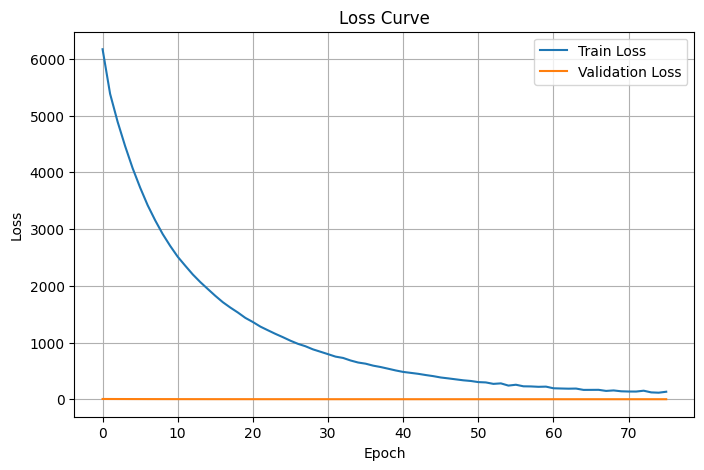

In [36]:
# -------- Plot Training vs Validation Loss ------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

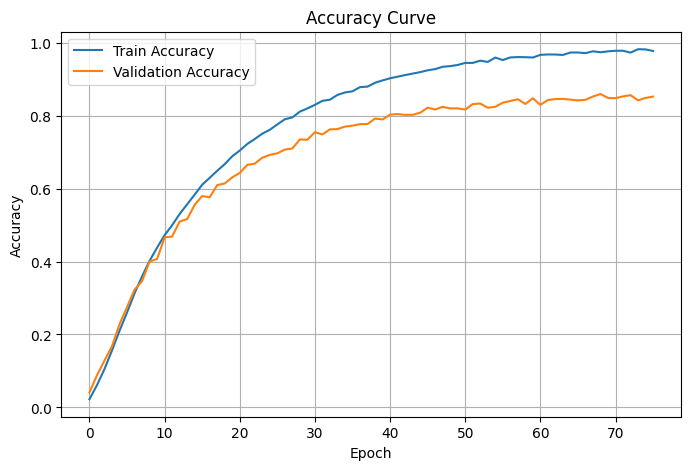

In [37]:
# -------- Plot Training vs Validation Accuracy ---------
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()

In [38]:
#                   TESTING & METRICS

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = model(X)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)



<Figure size 4200x3600 with 0 Axes>

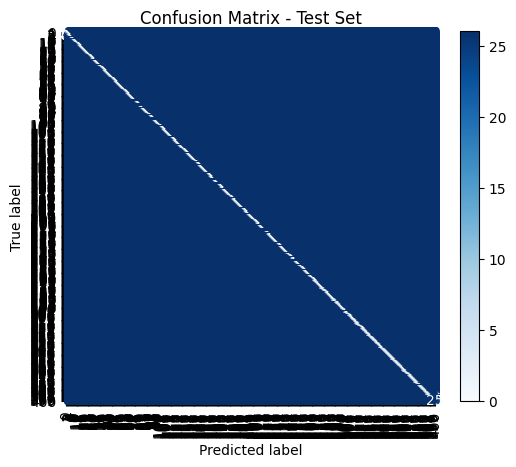


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        19
           1       0.81      0.68      0.74        19
           2       0.67      0.90      0.77        20
           3       0.88      0.70      0.78        20
           4       0.77      0.89      0.83        19
           5       0.66      0.95      0.78        20
           6       0.89      0.85      0.87        20
           7       0.81      0.85      0.83        20
           8       0.94      0.85      0.89        20
           9       0.95      1.00      0.97        19
          10       0.55      0.58      0.56        19
          11       0.81      0.68      0.74        19
          12       0.86      0.67      0.75        18
          13       1.00      0.85      0.92        20
          14       0.86      0.95      0.90        19
          15       0.69      1.00      0.82        18
          16       0.82      0.90      0.86        20
   

In [39]:
# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(42,36))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation='vertical')
plt.title("Confusion Matrix - Test Set")
plt.show()

# ---------------- Classification Report -------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))